In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("position_salaries.csv", index_col=0)
df.head(10)

,Level,Salary
Position,,
Business Analyst,1,45000
Junior Consultant,2,50000
Senior Consultant,3,60000
Manager,4,80000
Country Manager,5,110000
Region Manager,6,150000
Partner,7,200000
Senior Partner,8,300000
C-level,9,500000


In [3]:
#Splitting Data
X=df.Level.values
Y=df.Salary.values

In [4]:
#Reshaping Data
X=X.reshape(-1, 1)
Y=Y.reshape(-1, 1)

In [5]:
print(X.shape)
print(Y.shape)

(10, 1)
(10, 1)


In [6]:
X_train, X_test, Y_train, Y_test =train_test_split(X, Y, test_size=0.20, random_state=42)

In [7]:
lm= LinearRegression()

lm.fit(X_train, Y_train)

Y_pred=lm.predict(X_test)

In [8]:
r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)

In [9]:
print("R² Score (Accuracy):", r2)
print("MSE:", mse)
print("RMSE:", rmse)

R² Score (Accuracy): 0.8451346684575974
MSE: 7840057409.334131
RMSE: 88544.09867029045


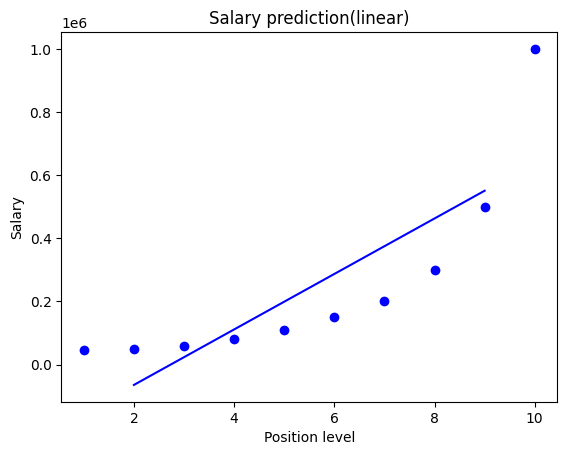

In [10]:
plt.scatter(X, Y, color='blue')
plt.plot(X_test, Y_pred, color='blue')
plt.title("Salary prediction(linear)")
plt.xlabel("Position level")
plt.ylabel("Salary")
plt.show()

In [11]:
poly_reg=PolynomialFeatures(degree=5)
X_poly=poly_reg.fit_transform(X)

In [12]:
X

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [13]:
X_poly

array([[1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00],
       [1.0000e+00, 2.0000e+00, 4.0000e+00, 8.0000e+00, 1.6000e+01,
        3.2000e+01],
       [1.0000e+00, 3.0000e+00, 9.0000e+00, 2.7000e+01, 8.1000e+01,
        2.4300e+02],
       [1.0000e+00, 4.0000e+00, 1.6000e+01, 6.4000e+01, 2.5600e+02,
        1.0240e+03],
       [1.0000e+00, 5.0000e+00, 2.5000e+01, 1.2500e+02, 6.2500e+02,
        3.1250e+03],
       [1.0000e+00, 6.0000e+00, 3.6000e+01, 2.1600e+02, 1.2960e+03,
        7.7760e+03],
       [1.0000e+00, 7.0000e+00, 4.9000e+01, 3.4300e+02, 2.4010e+03,
        1.6807e+04],
       [1.0000e+00, 8.0000e+00, 6.4000e+01, 5.1200e+02, 4.0960e+03,
        3.2768e+04],
       [1.0000e+00, 9.0000e+00, 8.1000e+01, 7.2900e+02, 6.5610e+03,
        5.9049e+04],
       [1.0000e+00, 1.0000e+01, 1.0000e+02, 1.0000e+03, 1.0000e+04,
        1.0000e+05]])

In [14]:
X.shape

(10, 1)

In [15]:
X_poly.shape

(10, 6)

In [16]:
lin_reg2=LinearRegression()
lin_reg2.fit(X_poly, Y)
Y_pred1=lin_reg2.predict(X_poly).reshape(-1)

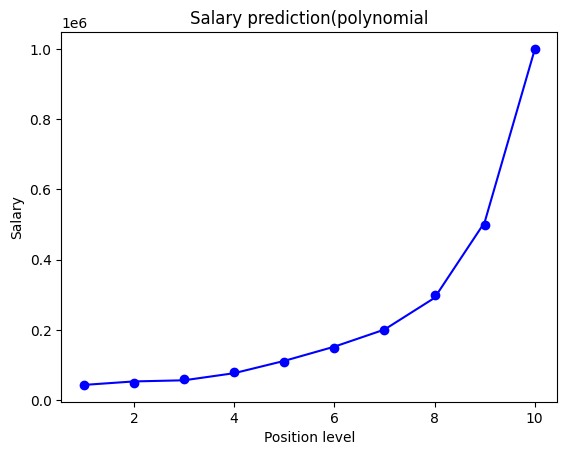

In [17]:
plt.scatter(X, Y, color='blue')
plt.plot(X, Y_pred1, color='blue')
plt.title("Salary prediction(polynomial")
plt.xlabel("Position level")
plt.ylabel("Salary")
plt.show()

In [18]:
r2 = r2_score(Y, Y_pred1)
mse = mean_squared_error(Y, Y_pred1)
rmse = np.sqrt(mse)

In [19]:
print("Polynomial Regression Accuracy (R²):", r2)
print("MSE:", mse)
print("RMSE:", rmse)

Polynomial Regression Accuracy (R²): 0.9997969027099755
MSE: 16382284.38228488
RMSE: 4047.5034752653246


In [20]:
lm.predict([[6.5]])

array([[331012.93103448]])

In [21]:
lin_reg2.predict(poly_reg.transform([[6.5]]))

array([[174878.07765173]])

In [22]:
data=pd.read_csv("Advertising.csv")
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [23]:
x=data[["TV","Radio", "Newspaper"]]
y=data[["Sales"]].values.reshape(-1)

In [24]:
poly=PolynomialFeatures(degree=5)
x_poly=poly.fit_transform(x)

In [25]:
x_poly

array([[1.00000000e+00, 2.30100000e+02, 3.78000000e+01, ...,
        4.73480266e+08, 8.66794561e+08, 1.58683026e+09],
       [1.00000000e+00, 4.45000000e+01, 3.93000000e+01, ...,
        1.41682016e+08, 1.62591830e+08, 1.86587570e+08],
       [1.00000000e+00, 1.72000000e+01, 4.59000000e+01, ...,
        7.01172823e+08, 1.05863348e+09, 1.59832898e+09],
       ...,
       [1.00000000e+00, 1.77000000e+02, 9.30000000e+00, ...,
        2.26728346e+04, 1.56028109e+04, 1.07374182e+04],
       [1.00000000e+00, 2.83600000e+02, 4.20000000e+01, ...,
        5.11767319e+08, 8.06642775e+08, 1.27142266e+09],
       [1.00000000e+00, 2.32100000e+02, 8.60000000e+00, ...,
        4.87028819e+04, 4.92691945e+04, 4.98420921e+04]])

In [26]:
x_poly.shape

(200, 56)

In [27]:
lin_reg=LinearRegression()
lin_reg.fit(x_poly, y)
y_pred=lin_reg.predict(x_poly).reshape(-1, 1)

In [28]:
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

In [29]:
print("Polynomial Regression Accuracy (R²):", r2)
print("MSE:", mse)
print("RMSE:", rmse)

Polynomial Regression Accuracy (R²): 0.9972869515445307
MSE: 0.07348493524617355
RMSE: 0.2710810492199216


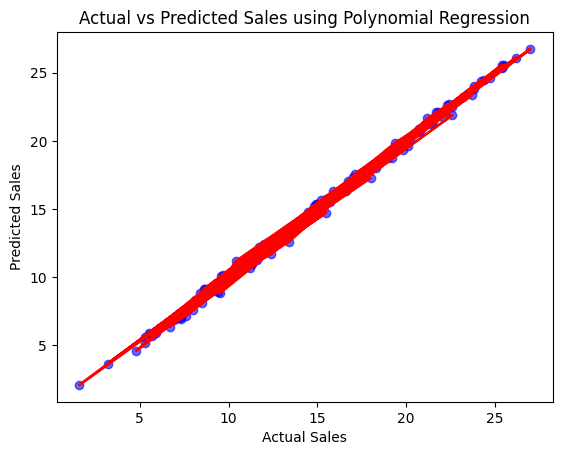

In [30]:
plt.scatter(y, y_pred, color = 'blue', alpha = 0.6)
plt.plot(y, y_pred, color = 'red', linewidth = 2, label = "Regression Line")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales using Polynomial Regression")
plt.show()

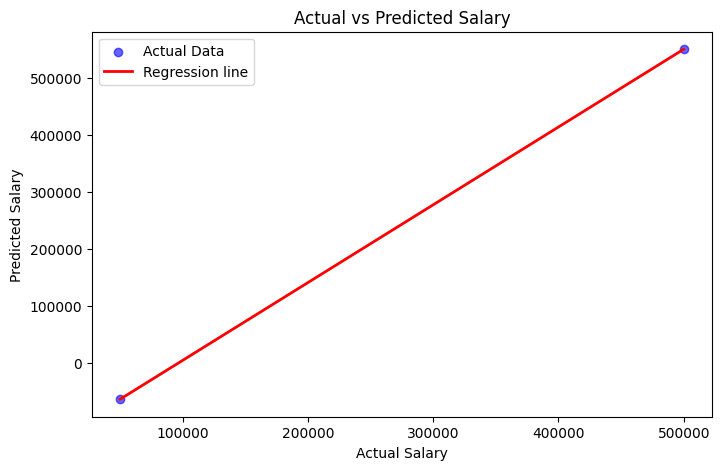

In [32]:
y_true = Y_test.flatten()
y_predictions = Y_pred.flatten()

sorted_idx = np.argsort(y_true)
y_sorted = y_true[sorted_idx]
y_pred_sorted = y_predictions[sorted_idx]

plt.figure(figsize=(8, 5))
plt.scatter(y_true, y_predictions, color='blue', alpha=0.6, label="Actual Data")
plt.plot(y_sorted, y_pred_sorted, color='red', linewidth=2, label="Regression line")

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.show()